<a href="https://colab.research.google.com/github/IT25101804/Group_58/blob/main/notebooks/IT25104127_handling_null_missing_values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Patient Readmission Prediction



---
**This notebook is Member 2's individual submission.**

- **Name:** Ekanayake E.W.T.G.B.
- **Student ID:** IT25104127
- **Assigned technique:** Handling null/missing values



## 1. Environment setup & data upload



In [ ]:
# If a library is missing in your Colab runtime, uncomment the line below and run it once.
# !pip install -q imbalanced-learn xgboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, f1_score, accuracy_score, recall_score,
                              precision_score)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Prefer XGBoost; fall back to sklearn's GradientBoostingClassifier if it isn't installed.
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available -> will use GradientBoostingClassifier instead.")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

In [ ]:
# --- Auto-injected: save every displayed figure as a PNG for the deliverable ---
import os as _os
_FIG_DIR = "eda_visualizations"
_os.makedirs(_FIG_DIR, exist_ok=True)
_FIG_COUNTER = {"n": 0}
_NOTEBOOK_TAG = "member2_IT25104127"
_orig_plt_show = plt.show
def _show_and_save(*args, **kwargs):
    _FIG_COUNTER["n"] += 1
    _fname = _os.path.join(_FIG_DIR, f"{_NOTEBOOK_TAG}_fig{_FIG_COUNTER['n']:02d}.png")
    try:
        plt.savefig(_fname, dpi=120, bbox_inches="tight")
    except Exception as _e:
        print("Could not save figure:", _e)
    return _orig_plt_show(*args, **kwargs)
plt.show = _show_and_save
print("Figure autosave enabled -> saving to", _os.path.abspath(_FIG_DIR))


Figure autosave enabled -> saving to /tmp/claude-0/-home-claude/dc8d500f-575b-53ca-8ba8-0b9ad12e8544/scratchpad/work/runs/IT25104127_handling_null_missing_values/eda_visualizations


In [ ]:
# --- Upload both files ---
# In Google Colab this opens a file picker. Select BOTH diabetic_data.csv and
# IDS_mapping.csv. If you're running this notebook outside Colab, it falls back to
# reading local files of those names in the working directory -- edit the paths
# below if your copies live somewhere else.
try:
    from google.colab import files
    print("Running in Google Colab. Please choose 'diabetic_data.csv' AND 'IDS_mapping.csv' to upload:")
    uploaded = files.upload()
    DATA_PATH = "diabetic_data.csv"
    IDS_MAPPING_PATH = "IDS_mapping.csv"
except ImportError:
    DATA_PATH = "diabetic_data.csv"
    IDS_MAPPING_PATH = "IDS_mapping.csv"
    print(f"Not running in Colab -- looking for local files '{DATA_PATH}' and '{IDS_MAPPING_PATH}'.")

# IMPORTANT data-loading detail (see Member 1 below for the full explanation):
# this dataset uses "?" as its disguised missing-value placeholder, AND uses the
# literal string "None" as a genuine category (e.g. "lab test not performed") in
# columns like max_glu_serum / A1Cresult. pandas' default NA parsing would silently
# read that "None" text as an actual missing value, which would be wrong here -- so
# we turn default NA parsing off and load the file exactly as it is written.
df = pd.read_csv(DATA_PATH, keep_default_na=False, na_values=[])
print("Loaded dataset:", df.shape)
df.head()

Not running in Colab -- looking for local files 'diabetic_data.csv' and 'IDS_mapping.csv'.


Loaded dataset: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# --- Load & parse IDS_mapping.csv ---
# This file stacks three small lookup tables (admission_type_id, discharge_disposition_id,
# admission_source_id -> description) in one CSV, separated by blank rows, so a plain
# pd.read_csv() won't parse it as one clean table. We parse it manually into three dicts.
import csv

def load_ids_mapping(path):
    tables = {}
    current_key, current_rows = None, []
    with open(path, newline="", encoding="utf-8") as f:
        for row in csv.reader(f):
            if len(row) < 2:
                continue
            col0, col1 = row[0].strip(), row[1].strip()
            if col1.lower() == "description" and col0.endswith("_id"):
                if current_key:
                    tables[current_key] = dict(current_rows)
                current_key, current_rows = col0, []
                continue
            if col0 == "" and col1 == "":
                continue
            if current_key and col0 != "":
                try:
                    current_rows.append((int(col0), col1))
                except ValueError:
                    pass
        if current_key:
            tables[current_key] = dict(current_rows)
    return tables

ids_mapping = load_ids_mapping(IDS_MAPPING_PATH)
for key, mapping in ids_mapping.items():
    print(f"{key}: {len(mapping)} codes decoded")

admission_type_map = ids_mapping["admission_type_id"]
discharge_disposition_map = ids_mapping["discharge_disposition_id"]
admission_source_map = ids_mapping["admission_source_id"]

print("\nExample decodes:")
print(" discharge_disposition_id 11 ->", discharge_disposition_map[11])
print(" discharge_disposition_id 1  ->", discharge_disposition_map[1])
print(" admission_type_id 1         ->", admission_type_map[1])

admission_type_id: 8 codes decoded
discharge_disposition_id: 30 codes decoded
admission_source_id: 25 codes decoded

Example decodes:
 discharge_disposition_id 11 -> Expired
 discharge_disposition_id 1  -> Discharged to home
 admission_type_id 1         -> Emergency


## 2. Individual EDA & preprocessing — Members 1 to 8



### Member 1 — Data understanding & initial EDA



Shape: (101766, 50)

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medica

                             count          mean           std      min  \
encounter_id              101766.0  1.652016e+08  1.026403e+08  12522.0   
patient_nbr               101766.0  5.433040e+07  3.869636e+07    135.0   
admission_type_id         101766.0  2.024006e+00  1.445403e+00      1.0   
discharge_disposition_id  101766.0  3.715642e+00  5.280166e+00      1.0   
admission_source_id       101766.0  5.754437e+00  4.064081e+00      1.0   
time_in_hospital          101766.0  4.395987e+00  2.985108e+00      1.0   
num_lab_procedures        101766.0  4.309564e+01  1.967436e+01      1.0   
num_procedures            101766.0  1.339730e+00  1.705807e+00      0.0   
num_medications           101766.0  1.602184e+01  8.127566e+00      1.0   
number_outpatient         101766.0  3.693572e-01  1.267265e+00      0.0   
number_emergency          101766.0  1.978362e-01  9.304723e-01      0.0   
number_inpatient          101766.0  6.355659e-01  1.262863e+00      0.0   
number_diagnoses         


Columns using '?' as a disguised missing-value placeholder:
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

...as a percentage of all rows:
weight               96.86
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64



Exact duplicate rows: 0


Shape after dropping exact duplicates: (101766, 50)
Patients with more than one encounter in the data: 16773

Encounters where discharge_disposition_id decodes to 'Expired': 1652
readmitted value counts for those encounters:
readmitted
NO    1652
Name: count, dtype: int64


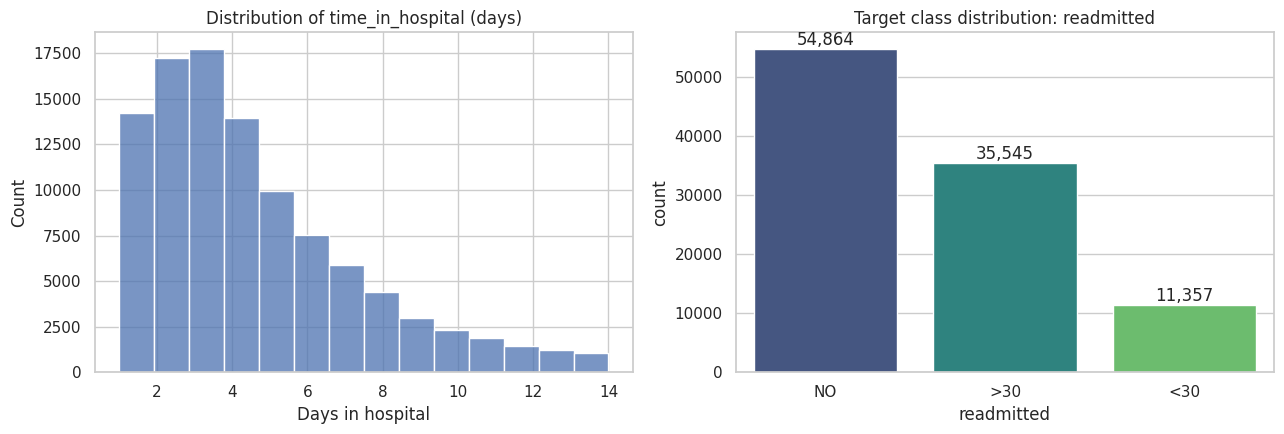

In [ ]:
# --- Member 1: Data understanding & initial EDA ---
df_m1 = df.copy()

print("Shape:", df_m1.shape)
print()
df_m1.info()
print()
print(df_m1.describe(include="number").T)

# Check for disguised missing values: "?" used as a placeholder string
disguised_missing = (df_m1 == "?").sum()
disguised_missing = disguised_missing[disguised_missing > 0].sort_values(ascending=False)
print("\nColumns using '?' as a disguised missing-value placeholder:")
print(disguised_missing)
print("\n...as a percentage of all rows:")
print((disguised_missing / len(df_m1) * 100).round(2))

# Exact duplicate rows
n_dupes = df_m1.duplicated().sum()
print(f"\nExact duplicate rows: {n_dupes}")
df_m1 = df_m1.drop_duplicates()
print("Shape after dropping exact duplicates:", df_m1.shape)

# Repeat patients (not deduplicated here -- flagged only)
repeat_patients = (df_m1["patient_nbr"].value_counts() > 1).sum()
print(f"Patients with more than one encounter in the data: {repeat_patients}")

# --- Using IDS_mapping.csv to decode discharge_disposition_id ---
df_m1["discharge_disposition_desc"] = df_m1["discharge_disposition_id"].map(discharge_disposition_map)
expired_mask = df_m1["discharge_disposition_desc"].str.contains("Expired", case=False, na=False)
print(f"\nEncounters where discharge_disposition_id decodes to 'Expired': {expired_mask.sum()}")
print("readmitted value counts for those encounters:")
print(df_m1.loc[expired_mask, "readmitted"].value_counts())

# --- Visualization 1: univariate histogram of a key numeric feature ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_m1["time_in_hospital"], bins=14, kde=False, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of time_in_hospital (days)")
axes[0].set_xlabel("Days in hospital")

# --- Visualization 2: target class bar chart ---
order = ["NO", ">30", "<30"]
sns.countplot(x="readmitted", data=df_m1, order=order, ax=axes[1], palette="viridis")
axes[1].set_title("Target class distribution: readmitted")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Interpretation.** `time_in_hospital` is right-skewed (most stays are 1–4 days, with a long tail out to 14), which is typical for length-of-stay data and something later members should keep in mind when scaling/handling outliers. The target bar chart shows the three-way split (`NO` 53.9%, `>30` 34.9%, `<30` 11.2%) that Member 8 will quantify precisely and address as class imbalance.

### Member 2 — OWN CONTRIBUTION — Handling null/missing values



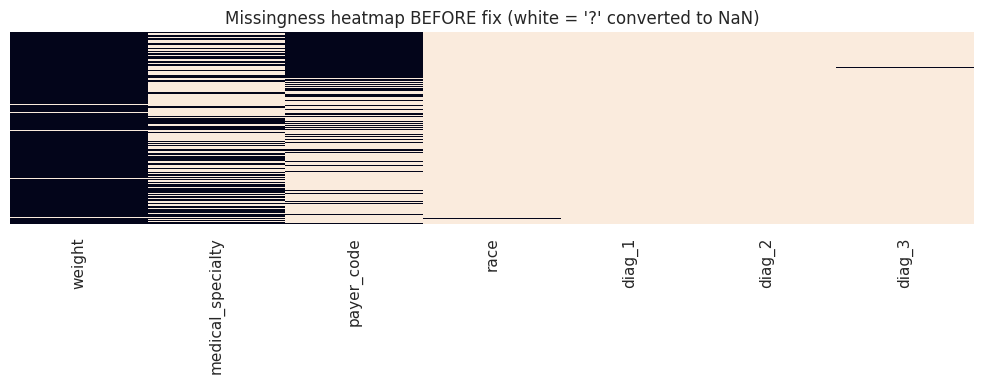

Missing % per column (after converting '?' to NaN):
weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

Dropping columns above 90% missing: ['weight']



Remaining missing values after imputation: 0


In [ ]:
# --- Member 2: Handling null/missing values ---
df_m2 = df_m1.copy()

# --- Visualization: missingness heatmap BEFORE the fix (on a comparable sample of columns) ---
missing_preview_cols = ["weight", "medical_specialty", "payer_code", "race", "diag_1", "diag_2", "diag_3"]
df_preview = df_m2[missing_preview_cols].replace("?", np.nan)
plt.figure(figsize=(10, 4))
sns.heatmap(df_preview.isnull(), cbar=False, yticklabels=False, cmap="rocket_r")
plt.title("Missingness heatmap BEFORE fix (white = '?' converted to NaN)")
plt.tight_layout()
plt.show()

# Convert disguised "?" placeholders to real NaN across the whole frame
# (Note: this dataset's literal "None" strings in max_glu_serum/A1Cresult are a real
#  category -- "test not performed" -- NOT a missing value, so we leave those alone.)
df_m2 = df_m2.replace("?", np.nan)

missing_pct = (df_m2.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("Missing % per column (after converting '?' to NaN):")
print(missing_pct)

# Drop columns above a justified missingness threshold
DROP_THRESHOLD = 90  # % missing
high_missing_cols = missing_pct[missing_pct > DROP_THRESHOLD].index.tolist()
print(f"\nDropping columns above {DROP_THRESHOLD}% missing: {high_missing_cols}")
df_m2 = df_m2.drop(columns=high_missing_cols)

# Impute remaining numeric columns with the median (defensive -- none are missing today)
numeric_cols = df_m2.select_dtypes(include="number").columns
for c in numeric_cols:
    if df_m2[c].isnull().sum() > 0:
        df_m2[c] = df_m2[c].fillna(df_m2[c].median())

# Impute remaining categorical columns: "Unknown" for heavily-missing columns, mode otherwise
categorical_cols = df_m2.select_dtypes(include="object").columns
MODE_VS_UNKNOWN_THRESHOLD = 30  # % missing
for c in categorical_cols:
    miss_share = df_m2[c].isnull().mean() * 100
    if miss_share == 0:
        continue
    if miss_share > MODE_VS_UNKNOWN_THRESHOLD:
        df_m2[c] = df_m2[c].fillna("Unknown")
    else:
        df_m2[c] = df_m2[c].fillna(df_m2[c].mode()[0])

print("\nRemaining missing values after imputation:", df_m2.isnull().sum().sum())